# Tutorial on using masking functions for MSA Transformer
# Getting Started
See the paper by [Rao et al 2021](https://proceedings.mlr.press/v139/rao21a.html) for details on the model

In this tutorial, I will show how to use the functions I have written to get probabilities of different paths to the same inital and final sequences. (I have recently adapted some of the functions so if you are getting errors, no problem just let me know)

## Setup

Please see this [link to installation instructions](https://github.com/facebookresearch/esm) for getting dependencies and installing esm

## Imports

In [1]:
from importlib import reload
import main #import evolution_with_context
import helper_functions as hp
import torch
import esm
import numpy as np
import time

## Some basics for the notebook
Best (and most important) things to know about jupyer:
- Anything you write on the last line, if not a variable assisgnment, will be printed out (see examples below) 
  - You can also separate things by a ',' to print more than one thing out
- ANY VARIABLE you set at ANY POINT will be saved until reassigned. This is *REALLY* really important. You are not re-running the whole code so make sure that you aren't using an old value on accident
- Following that...if you have a weird error, just restart the kernel and pray. I would say 10% of the time I don't understand what's happening, that fixes it
- Which also means....before you can say something works, just restart the kernel and pray. I would say 98% of the time there's no problem
- My advice is to take advantage of the cells, but be mindful and maybe re-run everything that doesn't take too long regularly
- This also means do not lump code that takes forever with code that does not. The beauty here is you can run the annoying part of the code and keep changing other stuff
- SAVE EVERYTHING. Future you will thank you for not having to rerun some calculation. np.save() will be your lifelong best friend 

Need help? Try typing 
>help(*function name*)

In [19]:
# Example
help(hp.read_fasta_to_data), help(np.save)

Help on function read_fasta_to_data in module helper_functions:

read_fasta_to_data(file_name)
    This is a function to convert a fasta file into a format readable by the transformer
    Input: 
        file_name: the path to a fasta file you want to use with the transformer
    Output:
        data: the data structure readable by the transformer

Help on function save in module numpy:

save(file, arr, allow_pickle=True, fix_imports=True)
    Save an array to a binary file in NumPy ``.npy`` format.
    
    Parameters
    ----------
    file : file, str, or pathlib.Path
        File or filename to which the data is saved.  If file is a file-object,
        then the filename is unchanged.  If file is a string or Path, a ``.npy``
        extension will be appended to the filename if it does not already
        have one.
    arr : array_like
        Array data to be saved.
    allow_pickle : bool, optional
        Allow saving object arrays using Python pickles. Reasons for disallowing
 

(None, None)

If you want to know what functions are available in my helper libraries (main and helper_functions), try
>dir(*module*)

In [15]:
# Example
dir(hp)

['Calc_nn',
 'Convert_fastaToNp',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'calc_model_prob',
 'cdist',
 'esm',
 'get_prob_nat',
 'math',
 'np',
 'random',
 'read_fasta_to_data',
 'replace_with_rand_mut',
 'torch',
 'tqdm']

# Important things for the MSATransformer (and doing protein stuff in general)

## FASTA FILE

A fasta file is a common way of storing an MSA. The format is
>\>Sequence1 name\
sequence1 \
\>Sequence2 name\
sequence2\
...etc

Ex:
>\>seq0\
MLSTIVCHDLNLVIGHNNKMPWHLPDDLKRVKQLTTGHTIVMGKNTYLSLGKPLPNRRNVVLTSDPSFSEGI\
\>seq2\
\---------------INKNQPWSSQEDKKHFSKVTKEGVVIMGRKTFEEIGKPLDKRKNIVLTGEPEYQQGSFSEGI


# Getting used to the model
The most important things you have to do for using it issssss.....
1. Load the model
    - get the alphabet and batch converter
2. Make the data readable to the transformer
    - So basically the transformer takes in data that is like a fasta file but instead of being one after another, it is just in a list like {(seq1_name, seq1), (seq2_name, seq2), ...}. I have a helper function to do this. Try typing help
3. Understand what is actually being outputted

## Running the basic model
The functions you need to get started are in helper_functions. Here we will load some sequences, read it to data, and then get some probabilities from the model

## 1. Loading 
The model will be the msa transformer. The alphabet tells us how to translate a fasta file into usable data for the transformer

In [2]:
model, alphabet = esm.pretrained.esm_msa1b_t12_100M_UR50S()

The alphabet contains tokens corresponding to all aa (not just natural), and other useful tokens. It also has some associated functions we can take advantage of-converting a letter to a token or vice versa

In [3]:
alphabet.all_toks

['<cls>',
 '<pad>',
 '<eos>',
 '<unk>',
 'L',
 'A',
 'G',
 'V',
 'S',
 'E',
 'R',
 'T',
 'I',
 'D',
 'P',
 'K',
 'Q',
 'N',
 'F',
 'Y',
 'M',
 'H',
 'W',
 'C',
 'X',
 'B',
 'U',
 'Z',
 'O',
 '.',
 '-',
 '<null_1>',
 '<mask>']

In [4]:
dir(alphabet)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_tokenize',
 'all_special_tokens',
 'all_toks',
 'append_eos',
 'append_toks',
 'cls_idx',
 'encode',
 'eos_idx',
 'from_architecture',
 'get_batch_converter',
 'get_idx',
 'get_tok',
 'mask_idx',
 'padding_idx',
 'prepend_bos',
 'prepend_toks',
 'standard_toks',
 'to_dict',
 'tok_to_idx',
 'tokenize',
 'unique_no_split_tokens',
 'unk_idx',
 'use_msa']

## 2. Making the data readable

In [22]:
help(hp.read_fasta_to_data)

Help on function read_fasta_to_data in module helper_functions:

read_fasta_to_data(file_name)
    This is a function to convert a fasta file into a format readable by the transformer
    Input: 
        file_name: the path to a fasta file you want to use with the transformer
    Output:
        data: the data structure readable by the transformer



In [12]:
# The final to be read
file_name = f'{protein}_data/hhfilter_alignment_split_context_55_percent.fasta'

# Input to get data out
data = hp.read_fasta_to_data(file_name)

# This converts a fasta file to a list of pairs. Each pair containing a sequence name and the sequence
type(data), data[0]

(list,
 ('>seq0',
  'MLSTIVCHDLNLVIGHNNKMPWHLPDDLKRVKQLTTGHTIVMGKNTYLSLGKPLPNRRNVVLTSDPSFSEGIDVIHSLGDISR-L--DGHVFIFGGQKLYEQTMDIVDDMYVTVIETKHMGDAFFPPYSFTDWEVESVEQGSADNGQP-PHKFLHLVR'))

<nl>Now that data can be converted, we want to use the converter associated with the transformer. This is basically a key that transfers the list of characters to numbers that you give the model as input

In [13]:
# This is just a converter to data we can use
batch_converter = alphabet.get_batch_converter()

# The output of conversion is labels, strs, and tokens. All we need are the tokens (just numbers representing sequences)
# We are only going to do this for one "batch" so batch_labels is a list with seq names and batch_strs is the actual sequence letters
# It is called batch whatever because you can split data into several batches (to run faster, more efficiently etc) See below link if interested
# https://medium.com/analytics-vidhya/when-and-why-are-batches-used-in-machine-learning-acda4eb00763

batch_labels, batch_strs, batch_tokens= batch_converter(data)

batch_tokens.shape, batch_labels[0][0], batch_strs[0][0], batch_tokens[0][0]

(torch.Size([1, 956, 159]),
 '>seq0',
 'MLSTIVCHDLNLVIGHNNKMPWHLPDDLKRVKQLTTGHTIVMGKNTYLSLGKPLPNRRNVVLTSDPSFSEGIDVIHSLGDISR-L--DGHVFIFGGQKLYEQTMDIVDDMYVTVIETKHMGDAFFPPYSFTDWEVESVEQGSADNGQP-PHKFLHLVR',
 tensor([ 0, 20,  4,  8, 11, 12,  7, 23, 21, 13,  4, 17,  4,  7, 12,  6, 21, 17,
         17, 15, 20, 14, 22, 21,  4, 14, 13, 13,  4, 15, 10,  7, 15, 16,  4, 11,
         11,  6, 21, 11, 12,  7, 20,  6, 15, 17, 11, 19,  4,  8,  4,  6, 15, 14,
          4, 14, 17, 10, 10, 17,  7,  7,  4, 11,  8, 13, 14,  8, 18,  8,  9,  6,
         12, 13,  7, 12, 21,  8,  4,  6, 13, 12,  8, 10, 30,  4, 30, 30, 13,  6,
         21,  7, 18, 12, 18,  6,  6, 16, 15,  4, 19,  9, 16, 11, 20, 13, 12,  7,
         13, 13, 20, 19,  7, 11,  7, 12,  9, 11, 15, 21, 20,  6, 13,  5, 18, 18,
         14, 14, 19,  8, 18, 11, 13, 22,  9,  7,  9,  8,  7,  9, 16,  6,  8,  5,
         13, 17,  6, 16, 14, 30, 14, 21, 15, 18,  4, 21,  4,  7, 10]))

#### As you can see, the shape a batch_tokens is (NUM_BATCHES, NUM_SEQ, SEQ_LEN). NUM_BATCHES is always 1 for us. And the (1,i)th element is an array of numbers corresponding to one sequence. This we can use as input for the model

## Understanding the ouput
Ok, so I have a helper function calc_model_prob, but we are just gonna do it out here. Let's get the output of the models and see if we can make sense of it
* REMEMBER TO CALL model.eval() and run with torch.no_grad() so it doesn't try and learn more
* If you are running on a cpu for funsies,I would not input more than like 50 sequences. It runs ~3sec/sequence. If you have a gpu, set the gpu variable to True and just have results = model(batch_tokens, repr_layers=[12], return_contacts=False)

In [15]:
# Set gpu if you want to use it
gpu=True
# Checks to make sure you have a gpu available (cuda))
device = torch.device("cuda:0" if (torch.cuda.is_available()) and gpu else "cpu")
print(f'Device is {device}')

# Puts everything on that device
model.to(device)
batch_tokens = batch_tokens.to(device)
num_seq = 50

# put model in evaluate model
model.eval()

start_time = time.time()
# this says, hey no gradient funny business
with torch.no_grad():
    # Results will be the ouput of the model. repr_layers = [12] just means we want the final output and 
    # return contacts we don't need
    results = model(batch_tokens[:,:num_seq], repr_layers=[12], return_contacts=False)

print(f'The model ran in {time.time()-start_time} seconds and the data type of results is {type(results)}')

Device is cuda:0
The model ran in 2.323059558868408 seconds and the data type of results is <class 'dict'>


### Ahhhh...the result is a dictionary...I wonder what the keys are?

In [65]:
results.keys()

dict_keys(['logits', 'representations'])

#### So whats a logit...is something akin to a log odds. Its the inverse of a softmax [here's a little explanation](https://deepai.org/machine-learning-glossary-and-terms/logit)
We can convert this to a probability with the softmax function, but we have to consider that this gives probabilities for more than just the natural amino acids (remember the tokens above)

In [68]:
# The shape is (NUM_BATCHES, NUM_SEQ, SEQ_LEN, NUM_POSSIBILITIES) for us, possiblitites should just be the 20 natural 
# amino acids and a gap (21)
results['logits'].shape, results['logits'][0,0,0]

(torch.Size([1, 50, 159, 33]),
 tensor([-12.9226, -22.9549, -23.2106, -23.2536,   1.4419,   2.3549,  -0.0711,
           1.1742,   1.9130,  -0.2961,   0.9980,   1.2621,   0.2014,   0.2842,
          -2.1592,   1.0077,   0.3037,   0.2287,  -1.3173,  -0.3395,   0.2599,
           1.4573,  -2.3086,  -0.0532,  -3.5908, -10.1364,  -9.3066, -10.1867,
         -11.9640, -14.1460,  -3.6383, -14.1447, -14.9030]))

In [71]:
# This is an array of the tokens corresponding to the natural amino acids, so we softmax across these and set others to 0
Vals = torch.tensor([
                    4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,
                    20, 21, 22, 23, 30
                ]).numpy()

logits = results["logits"]#[:,:,:,Vals]

# This converts the logits into actual probabilities (over the natural amino acids) with softmax
prob = torch.zeros(logits.shape).to(device) 
prob[:,:,:,Vals] = torch.softmax(logits[:,:,:,Vals], dim=3)

# Output the probabilites corresponding to the above logits (with ones we don't want zerod out and show sum is 1
prob[0,0,0], prob[0,0,0].sum()

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0874, 0.2179, 0.0193, 0.0669, 0.1401,
         0.0154, 0.0561, 0.0731, 0.0253, 0.0275, 0.0024, 0.0566, 0.0280, 0.0260,
         0.0055, 0.0147, 0.0268, 0.0888, 0.0021, 0.0196, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0005, 0.0000, 0.0000]),
 tensor(1.0000))

# PATH DEPENDENCE MODEL

## Running the model

Here we are running the function with only one file as input. If you input 2 files, the first one should be the sequences you want to start at and the second should have the same number of sequences and be the sequences you finished at. If you give one file, you can also choose if the positions will be mutated randomly or if the positions will only be mutated to amino acids already seen in that position in nature.

The input file should be in standard fasta file format with a '-' for a gap

**IF YOU WANT TO USE A CPU TELL ME, I don't think it can run as is**

In [72]:
help(main.get_path_probs)

Help on function get_path_probs in module main:

get_path_probs(model, alphabet, data_file_i, data_file_f=None, iters=40, num_seq=0, num_mask=0, perc_diff=10, rand=True, use_cuda=True)
    This is a function to get the probabilities of going from one sequence to another in *iters* random paths
    INPUT
        model: The model that you want to use to find the probabilities. This is coded for the MSA Transformer 
        but can be generalized to others (like esm1v)
        alphabet: The alphabet associated with the model. This says how to convert from letters to numbers to 
        input to model
        data_file_i: A string containing a path to a fasta file with N sequences. Each sequence represents one 
        starting sequence to analyze
        data_file_f: default-None. If none is provided, then data_file_i is comsidered as starting sequences and the 
        final ones are either selected randomly (rand=True)or by mutating num_mask positions to mutations already seen in nature

In [ ]:
# This just reloads the file with the function so I don't have to restart the kernel
reload(main)
model, alphabet = esm.pretrained.esm_msa1b_t12_100M_UR50S()
protein = 'DHFR'
initial_file = f'{protein}_data/hhfilter_alignment_split_context_55_percent.fasta'
final_file = None
num_mask = 10
iters = 2
num_seq = 9
use_cuda = True
save_filepath = f'output_path_dependence/DHFR/prob_product_{num_mask}_mut_rand'

# For all sequences it will take like 2.5*iters*num_seq*num_mask seconds to run on a gpu


In [ ]:
# prob_product is size [num_seq, iters]. Each row correponds to the probability of mutating from one to the other
# iters amount of time
start_time = time.time()
prob_product, prob_sep = main.get_path_probs(model, alphabet, initial_file, final_file, iters = iters, \
                                                num_seq = num_seq, num_mask = num_mask, use_cuda=use_cuda)
np.save(save_filepath, prob_product)
print(f'Time elapsed is {time.time()-start_time} seconds')

In [38]:
prob_product.shape

torch.Size([9, 20])

## VISUALIZING THE RESULTS

In [39]:
import matplotlib.pyplot as plt

This will just help show what the differences between paths are. We take N of the sequences for visualization purposes

The first plot shows the differences in probabilities between the paths

Text(0.5, 0, 'Difference in log probabilities')

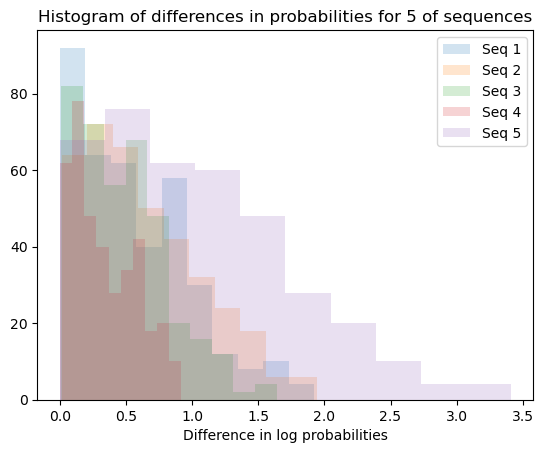

In [52]:
file_path = f'output_path_dependence/DHFR/prob_product_{num_mask}_mut_rand.npy'
prob_product = torch.from_numpy(np.load(file_path)).cuda()

N=5
fig, ax = plt.subplots(1) 
t_row = prob_product.unsqueeze(2) # This has shape n_seq, n_iters, 1 (So n_seq planes with n_iters rows, 1 col)
t_col = prob_product.unsqueeze(1) # This has shape n_seq, 1, n_iters (n_seq planes with 1 row and n_iters cols)
# When you subtract these it will broadcast the col one over so that you get the diff of all the values from each other for each plane
diff = torch.abs(t_row - t_col) # Size num_seq, num_iters, num_iters

# Create a diagonal mask
diagonal_mask = torch.eye(diff.size(1), dtype=torch.bool)

# Invert the mask to get non-diagonal elements
non_diagonal_mask = ~diagonal_mask

# Expand the mask to 3D to match the shape of the difference matrices
expanded_mask = non_diagonal_mask.unsqueeze(0).expand_as(diff)

# Apply the expanded mask to get non-diagonal elements
non_diagonal_elements = diff[expanded_mask]

#print(non_diagonal_elements.shape)


new = non_diagonal_elements.reshape(prob_product.size(0), prob_product.size(1) * (prob_product.size(1)-1)) 
#print('new shape', new.shape)

for i in range(N):
    #arr = prob_product.cpu()
    arr = new[i].cpu().numpy().flatten()

    #print(len(arr), len(arr[np.nonzero(arr)]))
    ax.hist(arr[np.nonzero(arr)], alpha = 0.2, label=f'Seq {i+1}')

plt.title(f'Histogram of differences in probabilities for {N} of sequences')
plt.legend()
plt.xlabel('Difference in log probabilities')

The second shows the actual values of the probabilites for each path

Text(0.5, 1.0, 'Values of log probabilies for 5 sequences')

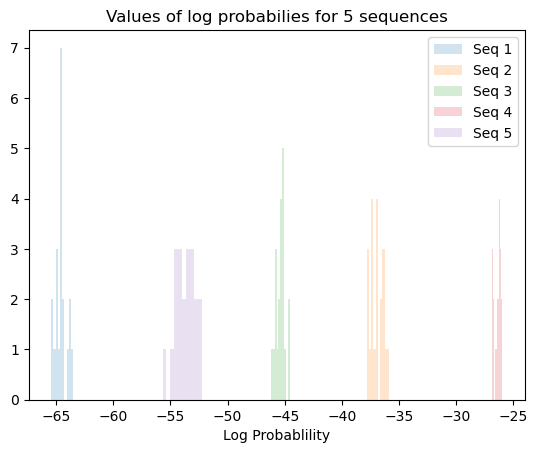

In [53]:
N=5

for i in range(N):
    plt.hist(prob_product[i].cpu(), alpha = 0.2, label=f'Seq {i+1}')
plt.legend()
plt.xlabel('Log Probablility')
plt.title('Values of log probabilies for 5 sequences')

Here they are compared. What is important to see is that the differences are close to the variance which means it does pretty well

380 380
380 380
380 380
380 380
380 380


Text(0.5, 1.0, 'Values of log probabilies for 5 sequences')

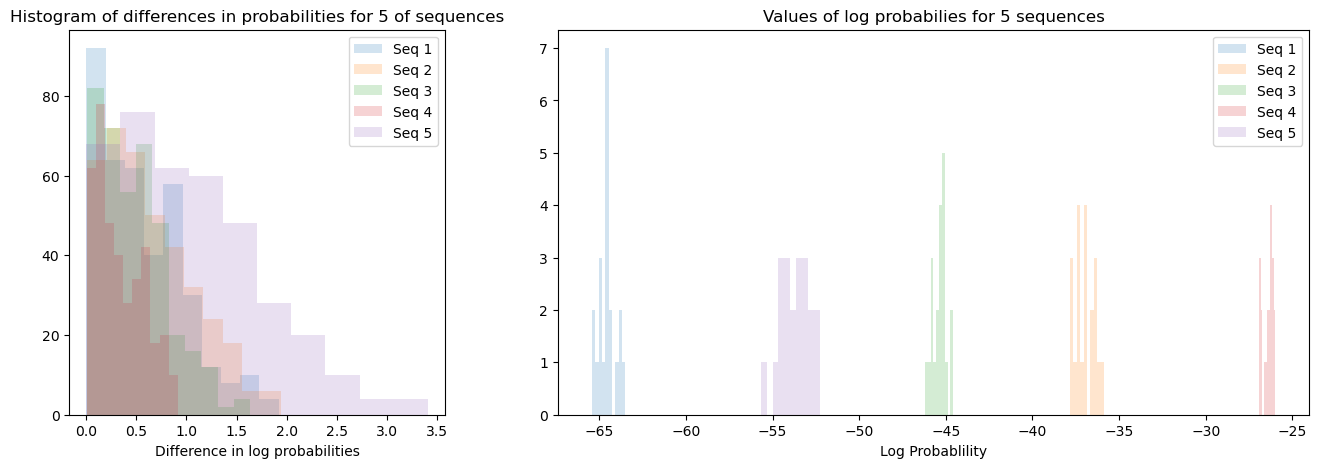

In [54]:
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(16, 5))

# Define the grid layout
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 2])  # This makes the second column twice as wide as the first

# Create subplots
ax1 = fig.add_subplot(gs[0, 0])  # First row, first column
ax2 = fig.add_subplot(gs[0, 1])  # Second row, first column

for i in range(N):
    #arr = prob_product.cpu()
    arr = new[i].cpu().numpy().flatten()

    print(len(arr), len(arr[np.nonzero(arr)]))
    ax1.hist(arr[np.nonzero(arr)], alpha = 0.2, label=f'Seq {i+1}')
ax1.set_title(f'Histogram of differences in probabilities for {N} of sequences')
ax1.legend()
ax1.set_xlabel('Difference in log probabilities')   
    
for i in range(N):
    plt.hist(prob_product[i].cpu(), alpha = 0.2, label=f'Seq {i+1}')
ax2.legend()
ax2.set_xlabel('Log Probablility')
ax2.set_title('Values of log probabilies for 5 sequences')
